In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

In [3]:
path: r"H:\MATÉRIAS TECNICAS\TERCEIRA ETAPA\PYTHON\Atividade5\Tabela4.csv"

In [9]:
df = pd.read_csv(
    "Tabela4.csv",
    sep=";",
    decimal=",",
    encoding="latin1",
    skiprows=1
)

df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [10]:
df = df.dropna(axis=1, how="all")

df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [14]:
df_ordenado = df.sort_values(by="2024", ascending=False)
df_ordenado[["Sigla", "Estado", "2024"]]

,Sigla,Estado,2024
6,DF,Distrito Federal,0.866
25,SP,São Paulo,0.838
23,SC,Santa Catarina,0.833
17,PR,Paraná,0.822
18,RJ,Rio de Janeiro,0.819
22,RS,Rio Grande do Sul,0.818
8,GO,Goiás,0.815
12,MT,Mato Grosso,0.812
10,MG,Minas Gerais,0.809
7,ES,Espírito Santo,0.804


In [15]:
df["Melhora"] = df["2024"] - df["1991"]

maior_melhora = df.sort_values(
    by="Melhora",
    ascending=False
)

maior_melhora[["Estado", "1991", "2024", "Melhora"]].head()

,Estado,1991,2024,Melhora
26,Tocantins,0.369,0.797,0.428
16,Piauí,0.362,0.764,0.402
9,Maranhão,0.357,0.745,0.388
20,Rondônia,0.407,0.786,0.379
14,Paraíba,0.382,0.760,0.378


In [16]:
pioraram = df[df["2024"] < df["1991"]]

pioraram[["Estado", "1991", "2024"]]

,Estado,1991,2024


In [17]:
anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")
df_longo.head()


['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Código,Estado,Melhora,Ano,IDH
0,AC,12,Acre,0.352,1991,0.402
1,AL,27,Alagoas,0.376,1991,0.370
2,AM,13,Amazonas,0.337,1991,0.430
3,AP,16,Amapá,0.287,1991,0.472
4,BA,29,Bahia,0.373,1991,0.386


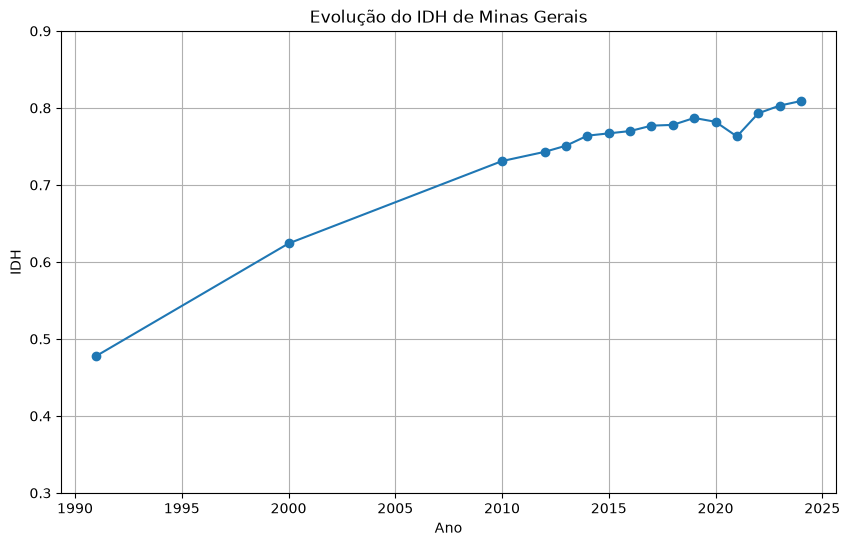

In [18]:
mg = df_longo[df_longo["Sigla"] == "MG"]

mg = mg.sort_values("Ano")

plt.figure(figsize=(10, 6))

plt.plot(
mg["Ano"],
mg["IDH"],
marker="o"
)

plt.title("Evolução do IDH de Minas Gerais")
plt.xlabel("Ano")
plt.ylabel("IDH")
plt.ylim(0.3, 0.9)
plt.grid()

plt.show()

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
grupo = grupo.sort_values("Ano")

ax.plot(
grupo["Ano"],
grupo["IDH"],
marker="o",
markersize=3,
linewidth=1.5,
label=sigla
)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)

ax.legend(
ncol=3,
bbox_to_anchor=(1.02, 1),
loc="upper left",
title="UF"
)

fig.tight_layout()

plt.show()

IndentationError: expected an indented block after 'for' statement on line 3 (138741230.py, line 4)